### Import Packages

In [1]:
import numpy as np
import pandas as pd 

from tqdm import tqdm

import os
import glob
import matplotlib.pyplot as plt

from tqdm import tqdm

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.io as io
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

### Import data & Display Some Images

In [2]:
train_path = r'C:\DriveWise-main\Driver_Activity\imgs\train'
for folder in glob.glob(train_path+'/*'):
    folder_name = folder.split('/')[-1]
    print(f'{folder_name} : {len(os.listdir(folder))} images')

C:\DriveWise-main\Driver_Activity\imgs\train\c0 : 2489 images
C:\DriveWise-main\Driver_Activity\imgs\train\c1 : 2267 images
C:\DriveWise-main\Driver_Activity\imgs\train\c2 : 2317 images
C:\DriveWise-main\Driver_Activity\imgs\train\c3 : 2346 images
C:\DriveWise-main\Driver_Activity\imgs\train\c4 : 2326 images
C:\DriveWise-main\Driver_Activity\imgs\train\c5 : 2312 images
C:\DriveWise-main\Driver_Activity\imgs\train\c6 : 2325 images
C:\DriveWise-main\Driver_Activity\imgs\train\c7 : 2002 images
C:\DriveWise-main\Driver_Activity\imgs\train\c8 : 1911 images
C:\DriveWise-main\Driver_Activity\imgs\train\c9 : 2129 images


In [3]:
classes = {
    'c0': 'safe driving',
    'c1': 'texting - right',
    'c2': 'talking on the phone - right',
    'c3': 'texting - left',
    'c4': 'talking on the phone - left',
    'c5': 'operating the radio',
    'c6': 'drinking',
    'c7': 'reaching behind',
    'c8': 'hair and makeup',
    'c9': 'talking to passenger'
}


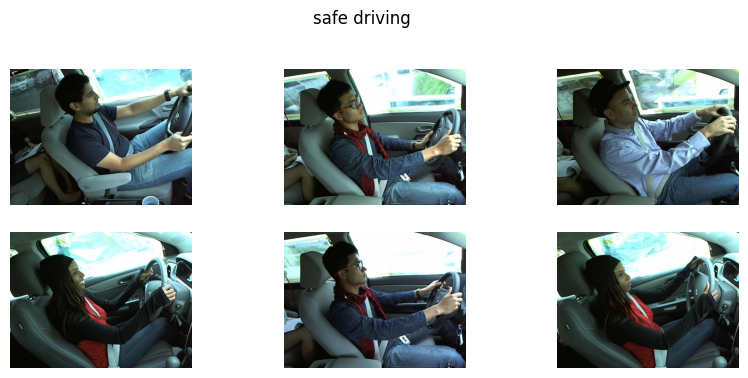

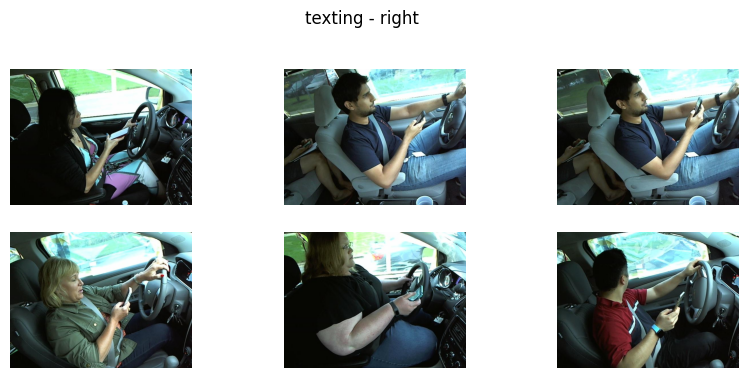

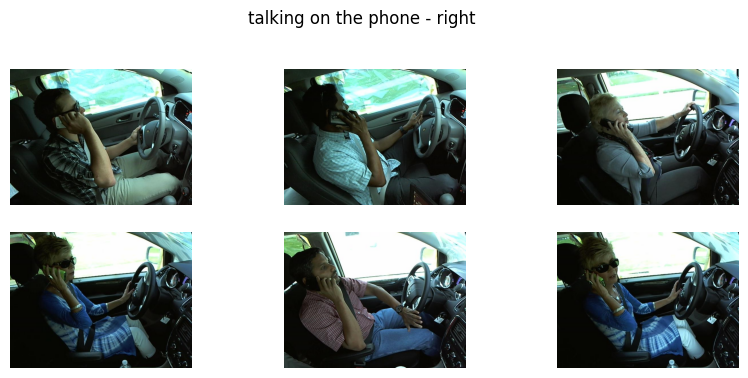

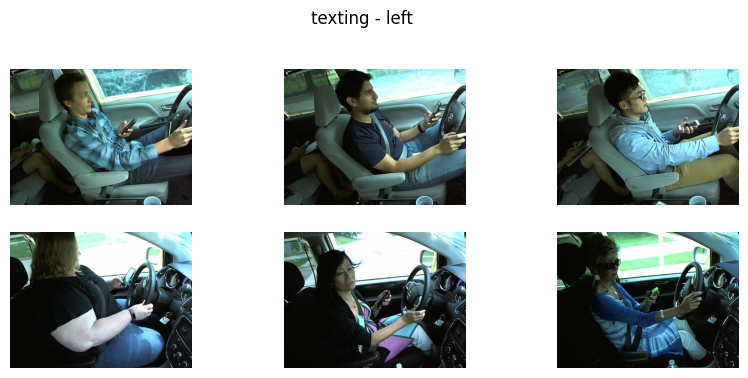

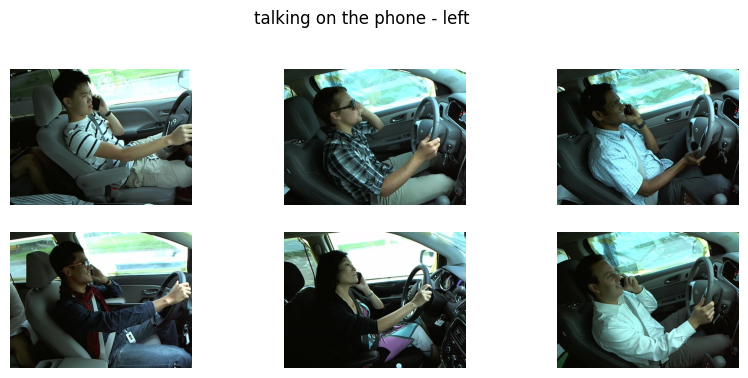

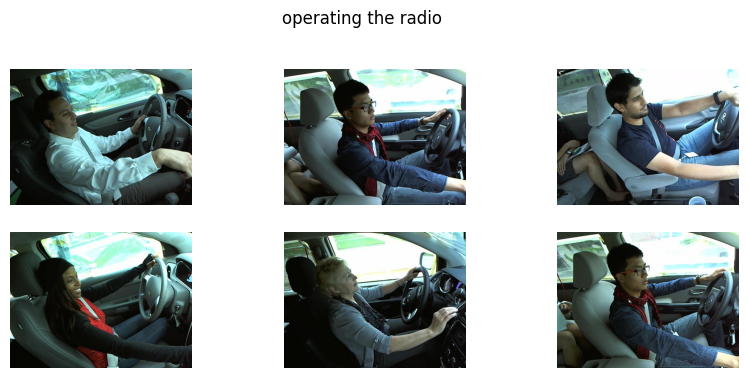

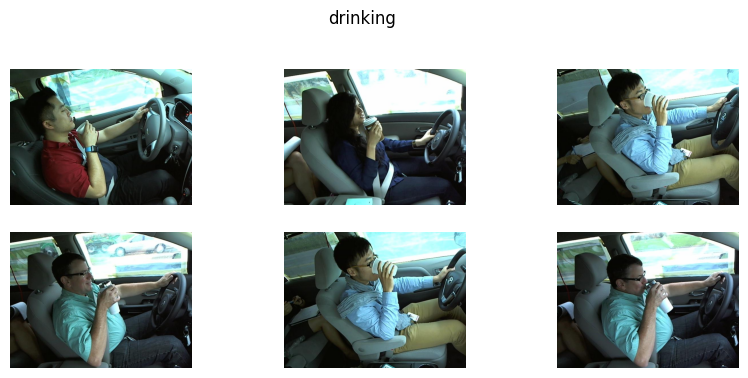

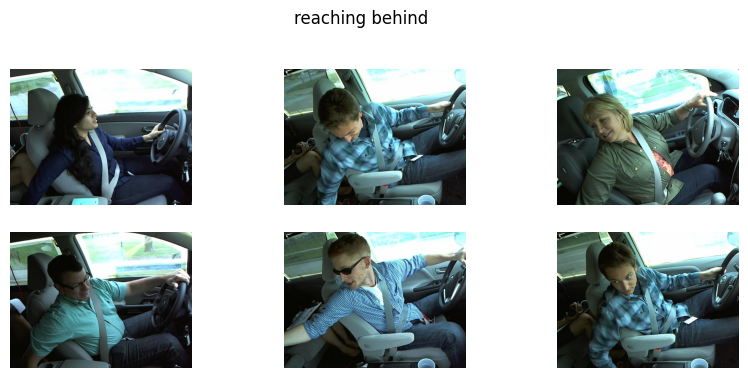

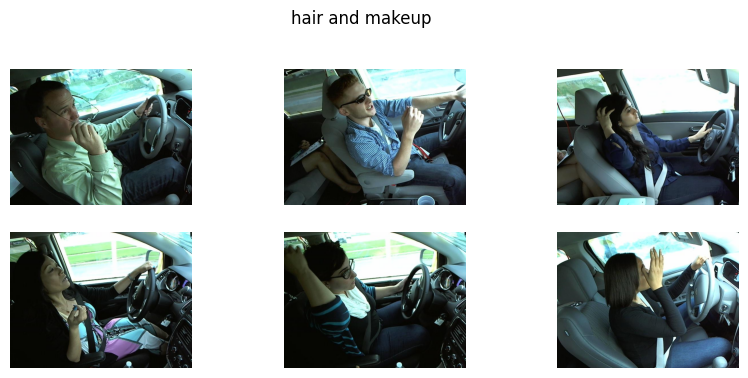

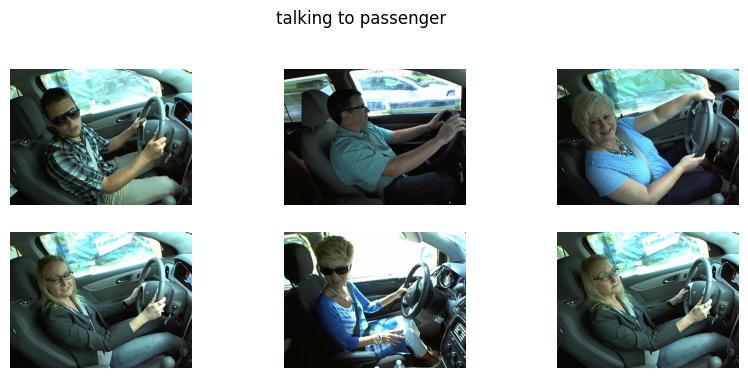

In [4]:
classes = {
    'c0': 'safe driving',
    'c1': 'texting - right',
    'c2': 'talking on the phone - right',
    'c3': 'texting - left',
    'c4': 'talking on the phone - left',
    'c5': 'operating the radio',
    'c6': 'drinking',
    'c7': 'reaching behind',
    'c8': 'hair and makeup',
    'c9': 'talking to passenger'
}

def show_images(folder_path, num):
    """
    Description:
        Display a random selection of images from the specified folder path.

    Parameters:
        - folder_path (str): The path to the folder containing the images.
        - num (int): The number of images to display.

    Returns:
        None
    """
    images = glob.glob(folder_path + '/*')
    selected_images = np.random.choice(images, num, replace=False)
    
    fig = plt.figure(figsize=(10, 6))
    columns = 3
    rows = (len(selected_images) // columns) + 1
    for i, image_file in enumerate(selected_images):
        img = plt.imread(image_file)
        ax = fig.add_subplot(rows, columns, i + 1)
        ax.imshow(img)
        ax.axis('off')
    class_ = folder_path.split(os.path.sep)[-1]  # Extract class label correctly
    plt.suptitle(classes[class_])
    plt.show()

# show some random images from each class 
for folder in glob.glob(train_path + '/*'):
    show_images(folder, 6)

In [5]:
img_path = r'C:\DriveWise-main\Driver_Activity\imgs\train\c1\img_100021.jpg'
img = io.read_image(img_path)
img.shape

torch.Size([3, 480, 640])

### BaseLine CNN

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 37 * 37, 512)  # Adjusted input size based on the output of conv2
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 37 * 37)  # Adjusted reshape based on the output size of conv2
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = BaselineCNN(num_classes=10)

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(1.0, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [8]:
dataset = datasets.ImageFolder(root=train_path, transform=train_transform)

In [9]:
dataset

Dataset ImageFolder
    Number of datapoints: 22424
    Root location: C:\DriveWise-main\Driver_Activity\imgs\train
    StandardTransform
Transform: Compose(
               Resize(size=(150, 150), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1), scale=(1.0, 1.2))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [10]:
class2idx = dataset.class_to_idx
class_indices = {v:k for k, v in class2idx.items()}
class_indices

{0: 'c0',
 1: 'c1',
 2: 'c2',
 3: 'c3',
 4: 'c4',
 5: 'c5',
 6: 'c6',
 7: 'c7',
 8: 'c8',
 9: 'c9'}

In [11]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

In [12]:
# Split the dataset into training and validation sets
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [13]:
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform

In [14]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu'):
    """
    Description:
        Train the given model using the provided data loaders and optimization parameters.

    Parameters:
        - model (torch.nn.Module): The neural network model to train.
        - train_loader (torch.utils.data.DataLoader): DataLoader for training data.
        - val_loader (torch.utils.data.DataLoader): DataLoader for validation data.
        - criterion (torch.nn.Module): The loss function.
        - optimizer (torch.optim.Optimizer): The optimizer used for updating model parameters.
        - num_epochs (int): Number of training epochs (default: 10).
        - device (str): Device to run the training on (default: 'cuda').

    Returns:
        - model (torch.nn.Module): The trained model.
        - history (dict): A dictionary containing training history with keys:
            - 'train_loss': List of training losses for each epoch.
            - 'train_acc': List of training accuracies for each epoch.
            - 'val_loss': List of validation losses for each epoch.
            - 'val_acc': List of validation accuracies for each epoch.

    """
    
    model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in tqdm(range(num_epochs)):
        # Training phase
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train_images = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train_images += labels.size(0)
            

        train_accuracy = 100 * correct_train / total_train_images
        avg_train_loss = train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val_images = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct_val += (predicted == labels).sum().item()
                total_val_images += labels.size(0)
                

        val_accuracy = 100 * correct_val / total_val_images
        avg_val_loss = val_loss / len(val_loader)

        # Print epoch statistics
        print(f"Epoch [{epoch+1}/{num_epochs}]\nTrain Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%")

        # Save history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

    return model, history

In [20]:
# Continue training from the last epoch or start fresh
trained_model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=6)

# Debugging: Print dataset size and class distribution
print(f"Training Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")
class_counts = {class_indices[i]: 0 for i in range(10)}
for _, label in train_dataset:
    class_counts[class_indices[label]] += 1
print("Class Distribution in Training Dataset:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")



 17%|█▋        | 1/6 [09:42<48:30, 582.17s/it]

Epoch [1/6]
Train Loss: 0.5261, Train Acc: 82.43%, Val Loss: 0.0951, Val Acc: 97.32%


 33%|███▎      | 2/6 [20:54<42:19, 634.91s/it]

Epoch [2/6]
Train Loss: 0.0334, Train Acc: 99.05%, Val Loss: 0.0460, Val Acc: 98.82%


 50%|█████     | 3/6 [31:56<32:22, 647.57s/it]

...

 83%|████████▎ | 5/6 [54:09<10:59, 659.14s/it]

Epoch [5/6]
Train Loss: 0.0016, Train Acc: 99.97%, Val Loss: 0.0313, Val Acc: 99.24%


100%|██████████| 6/6 [1:05:22<00:00, 653.67s/it]

Epoch [6/6]
Train Loss: 0.0282, Train Acc: 99.12%, Val Loss: 0.0717, Val Acc: 98.26%
Training Dataset Size: 17939
Validation Dataset Size: 4485


Class Distribution in Training Dataset:
c0: 1998
c1: 1789
c2: 1887
c3: 1886
c4: 1837
c5: 1818
c6: 1868
c7: 1593
c8: 1539
c9: 1724


In [21]:
def plot_performance(history):
    """
    Description:
        Plot the training and validation loss, as well as training and validation accuracy over epochs.

    Parameters:
        - history (dict): A dictionary containing training history with keys:
        - 'train_loss': List of training losses for each epoch.
        - 'train_acc': List of training accuracies for each epoch.
        - 'val_loss': List of validation losses for each epoch.
        - 'val_acc': List of validation accuracies for each epoch.

    Returns:
        None
    """
    
    epochs = range(1, len(history['train_loss']) + 1)

    # Plot loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

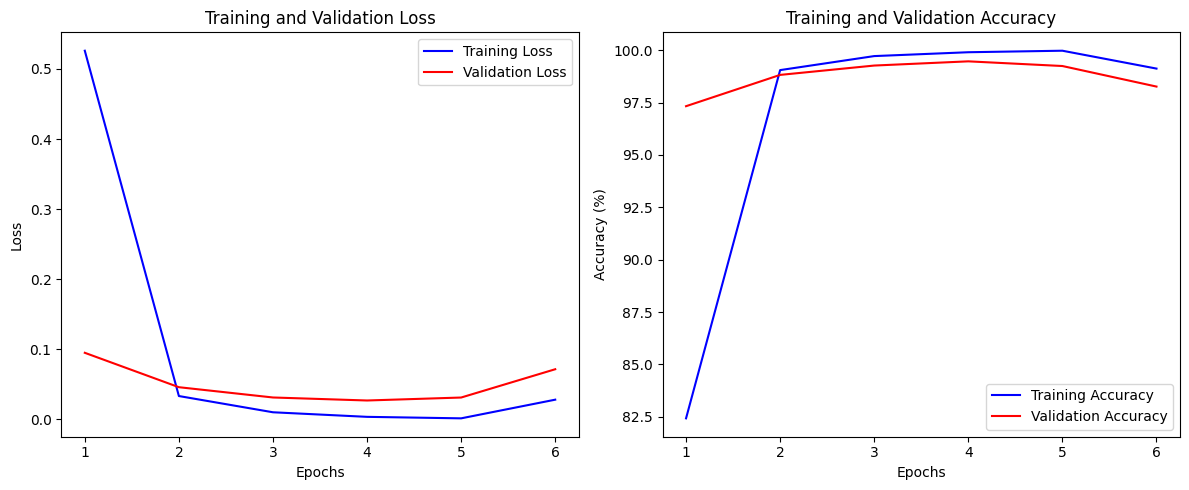

In [22]:
plot_performance(history)

> The issue here appears to be memory crashes due to the large size of the images. I tried to solve this issue by reducing batch size and simplifying the model architecture, but the problem persisted. As a solution, resizing the images from (480, 640) to (150, 150) has resolved the problem.

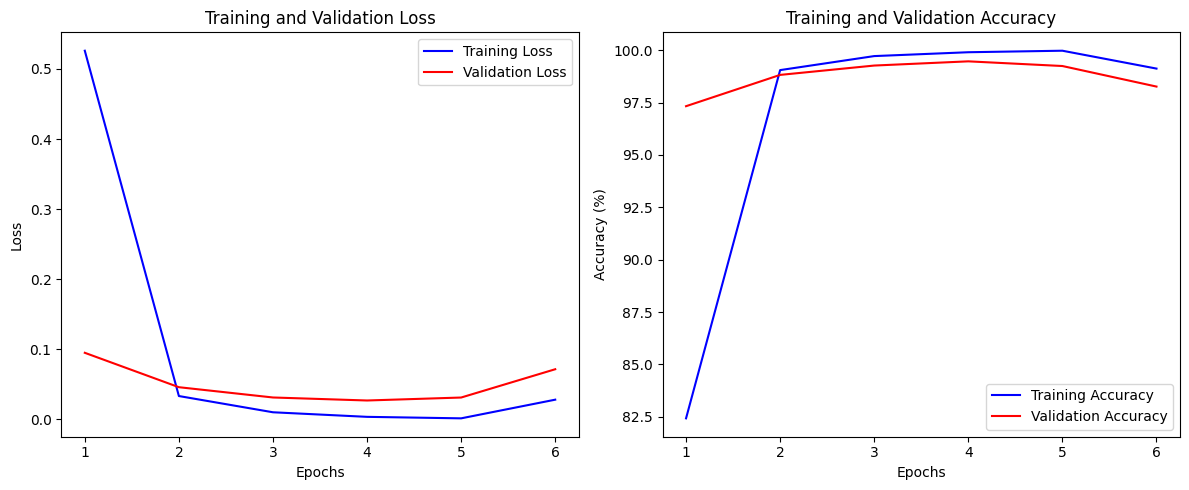

In [23]:
plot_performance(history)

### Test model on Test Data

In [33]:
from PIL import Image
import glob
import torch
 
 # Define the test_transform
test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def predict_folder(folder_path, model, test_transform, device):
    probabilities_per_image = []
    images = []

    for img_path in glob.glob(folder_path + '/*'):
        image = Image.open(img_path)
        image = test_transform(image).unsqueeze(0)  # batch dimension

        model.eval()
        with torch.no_grad():
            image = image.to(device)
            output = model(image)

        # Apply softmax to obtain probabilities
        probabilities = torch.softmax(output, dim=1)
        probabilities = probabilities.squeeze(0).tolist()

        images.append(img_path.split('/')[-1])
        probabilities_per_image.append(probabilities)

    return images, probabilities_per_image


In [34]:
# Example usage
folder_path = r'C:\DriveWise-main\Driver_Activity\imgs\test'
images, probabilities_per_image = predict_folder(folder_path, trained_model, test_transform, device)


In [35]:
len(probabilities_per_image)

79726

In [36]:
df1 = pd.DataFrame({'img': images})
df2 = pd.DataFrame(probabilities_per_image, columns = ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9'])
final_sub = pd.concat((df1, df2), axis=1)
final_sub

,img,c0,c1,c2,c3,c4,c5,c6,c7,c8,c9
0,C:\DriveWise-main\Driver_Activity\imgs\test\im...,2.795416e-15,1.429856e-16,2.475722e-12,4.614343e-18,4.066623e-15,1.000000e+00,8.391400e-14,5.115127e-15,2.867246e-16,7.843218e-10
1,C:\DriveWise-main\Driver_Activity\imgs\test\im...,4.087637e-04,3.190082e-02,1.950262e-04,1.685756e-05,4.525406e-06,3.346046e-04,2.796447e-06,9.670691e-01,5.877284e-05,8.649604e-06
2,C:\DriveWise-main\Driver_Activity\imgs\test\im...,1.919548e-02,1.207171e-02,6.878228e-04,1.917933e-04,5.155073e-08,9.572803e-05,2.107949e-07,2.060790e-03,1.597077e-04,9.655367e-01
3,C:\DriveWise-main\Driver_Activity\imgs\test\im...,2.884522e-03,8.688449e-07,6.232888e-06,1.206940e-02,9.036162e-01,6.215232e-05,3.639623e-03,7.688578e-04,7.694526e-02,6.808319e-06
4,C:\DriveWise-main\Driver_Activity\imgs\test\im...,5.568340e-01,3.989771e-02,2.207666e-08,3.219990e-01,1.673217e-02,2.012589e-02,2.135111e-09,1.631438e-06,9.548841e-03,3.486074e-02
...,...,...,...,...,...,...,...,...,...,...,...
79721,C:\DriveWise-main\Driver_Activity\imgs\test\im...,1.019939e-03,4.650933e-04,1.071505e-05,3.745806e-05,1.976780e-03,4.300124e-05,6.120382e-07,9.229735e-01,7.306700e-02,4.058814e-04
79722,C:\DriveWise-main\Driver_Activity\imgs\test\im...,1.349095e-01,1.140081e-03,9.084665e-06,8.639009e-01,1.491389e-06,3.136962e-05,3.023012e-06,3.108523e-08,8.931755e-07,3.710632e-06
79723,C:\DriveWise-main\Driver_Activity\imgs\test\im...,4.109120e-06,2.199581e-08,8.245183e-05,4.361060e-08,7.620830e-01,1.468142e-04,9.532844e-05,2.364842e-01,1.103744e-03,3.455462e-07
79724,C:\DriveWise-main\Driver_Activity\imgs\test\im...,1.180938e-09,3.572879e-10,5.135267e-07,3.071752e-11,1.646008e-05,5.691469e-07,9.971205e-01,2.822214e-03,3.973422e-05,2.475169e-09


In [37]:
final_sub.isnull().sum()

img    0
c0     0
c1     0
c2     0
c3     0
c4     0
c5     0
c6     0
c7     0
c8     0
c9     0
dtype: int64

In [38]:
final_sub.to_csv('final_sub.csv', index=False)

### Transfer Learning

In [39]:
transfer_model = models.resnet18(pretrained=True)
num = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(num, 10)

trained_transfer_model, history = train_model(transfer_model, train_loader, val_loader, criterion, optimizer, num_epochs=6)

c:\Users\1812a\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\1812a\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
 17%|█▋        | 1/6 [09:02<45:10, 542.15s/it]

Epoch [1/6]
Train Loss: 2.5418, Train Acc: 8.72%, Val Loss: 2.5518, Val Acc: 8.21%


 33%|███▎      | 2/6 [17:57<35:53, 538.30s/it]

Epoch [2/6]
Train Loss: 2.5422, Train Acc: 8.87%, Val Loss: 2.5511, Val Acc: 8.49%


 50%|█████     | 3/6 [26:53<26:51, 537.21s/it]

...

Epoch [4/6]
Train Loss: 2.5415, Train Acc: 8.81%, Val Loss: 2.5550, Val Acc: 8.41%


 83%|████████▎ | 5/6 [44:44<08:56, 536.04s/it]

Epoch [5/6]
Train Loss: 2.5429, Train Acc: 8.49%, Val Loss: 2.5489, Val Acc: 8.25%


100%|██████████| 6/6 [53:39<00:00, 536.56s/it]

Epoch [6/6]
Train Loss: 2.5425, Train Acc: 8.72%, Val Loss: 2.5577, Val Acc: 8.32%


In [40]:
# Save the trained model
torch.save(trained_model.state_dict(), r'C:\DriveWise-main\Driver_Activity\modeltrain\baselineCNN_model.pth')


In [2]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import os

# Define the CNN model architecture
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 37 * 37, 512)  # Adjusted input size based on the output of conv2
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 37 * 37)  # Adjusted reshape based on the output size of conv2
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def load_model(model_path):
    model = BaselineCNN(num_classes=10)
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))
    # Filter unexpected keys
    state_dict = {k: v for k, v in checkpoint.items() if k in model.state_dict()}
    # Load state dictionary
    model.load_state_dict(state_dict, strict=False)
    # Set the model to evaluation mode
    model.eval()
    return model


def predict_image_class(image_path, model):
    
    test_transform = transforms.Compose([
        transforms.Resize((150, 150)),  
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    try:
        
        image = Image.open(image_path)
    except Exception as e:
        print(f"Error loading image: {e}")
        return None, None, None

    
    image = test_transform(image).unsqueeze(0)  

    
    with torch.no_grad():
        output = model(image)

    
    predicted_class = torch.argmax(output, dim=1).item()

    
    classes = {
        0: {'label': 'c0', 'description': 'safe driving'},
        1: {'label': 'c1', 'description': 'texting'},
        2: {'label': 'c2', 'description': 'talking on the phone'},
        3: {'label': 'c3', 'description': 'texting'},
        4: {'label': 'c4', 'description': 'talking on the phone'},
        5: {'label': 'c5', 'description': 'operating the radio'},
        6: {'label': 'c6', 'description': 'drinking'},
        7: {'label': 'c7', 'description': 'reaching behind'},
        8: {'label': 'c8', 'description': 'hair and makeup'},
        9: {'label': 'c9', 'description': 'talking to passenger'}
    }

    predicted_label = classes[predicted_class]['label']
    predicted_desc = classes[predicted_class]['description']

    return predicted_label, predicted_desc, image.squeeze()


model_path = r"C:\DriveWise-main\Driver_Activity\modeltrain\baselineCNN_model.pth"

image_path = r"C:\DriveWise-main\Driver_Activity/imgs/train/c3/img_207.jpg"


if not os.path.exists(model_path):
    print("Model file not found.")
else:
    
    model = load_model(model_path)

    
    if model is not None:
       
        predicted_class, predicted_desc, image = predict_image_class(image_path, model)

        if predicted_class is not None:
            
            
            print("Predicted description:", predicted_desc)

           
            

Predicted description: texting
